# Phase 3 &mdash; Modeling

The final stage of the pipeline: train a loan-default classifier on the Gold Delta tables and compare it to the Phase 2 baseline.

### Inputs
- `workspace.default.gold_loans_train` (200k rows)
- `workspace.default.gold_loans_val` (50k rows)
- `workspace.default.gold_loans_test` (314k rows &mdash; full 2017 holdout)

### Output
A fitted, persisted Logistic Regression pipeline covering imputation, categorical encoding, scaling, and the classifier itself, plus AUC-ROC / AUC-PR metrics on train, validation, and test.

## A note on the modeling library

We originally planned to use Spark MLlib here so the entire pipeline &mdash; from Bronze to model fit &mdash; would live inside Spark. In practice, the Databricks environment available for this project runs all user notebooks on a shared serverless cluster that enforces a strict access policy on the underlying Java engine. That policy blocks the feature-engineering classes MLlib depends on (`Imputer`, `StringIndexer`, `OneHotEncoder`, `VectorAssembler`), so an MLlib pipeline cannot be constructed on this cluster.

The Bronze, Silver, and Gold layers are still produced entirely in Spark + Delta Lake &mdash; that's where the scalable work lives. For the model-fit step we load the ~200k-row Gold training set into pandas and use scikit-learn's equivalent API. This is a small, well-understood tradeoff: the dataset easily fits in driver memory at this stage, and scikit-learn's `LogisticRegression` produces results that are directly comparable to what MLlib would have produced (both implement regularized logistic regression with L-BFGS). We flag this choice in the Phase 3 report under *Challenges & Lessons Learned*.

## Phase 2 baseline numbers

From `models/model_results.csv`:

| Model | Val AUC-ROC | Val AUC-PR |
|---|---|---|
| LogisticRegression (baseline)   | 0.7121 | 0.3757 |
| DecisionTree (tuned)            | 0.7010 | 0.3572 |
| XGBoost (tuned)                 | 0.7238 | 0.3931 |
| HistGradientBoosting (tuned)    | 0.7233 | 0.3933 |

Target: the Phase 3 Logistic Regression should land within about 0.01 AUC-ROC of the Phase 2 Logistic Regression.

In [0]:
try:
    spark  # type: ignore[name-defined]
except NameError:
    from pyspark.sql import SparkSession
    spark = SparkSession.builder.appName("phase3-model").getOrCreate()

TRAIN_TABLE = "workspace.default.gold_loans_train"
VAL_TABLE   = "workspace.default.gold_loans_val"
TEST_TABLE  = "workspace.default.gold_loans_test"
LABEL = "charged_off"

## Step 1 &mdash; Load the Gold tables

Pull the three Gold Delta tables into pandas DataFrames. This is the point where Spark work ends and the modeling work begins.

In [0]:
import time
t0 = time.time()
train_df = spark.table(TRAIN_TABLE).toPandas()
val_df   = spark.table(VAL_TABLE).toPandas()
test_df  = spark.table(TEST_TABLE).toPandas()
print(f"Loaded in {time.time() - t0:.1f}s")
print(f"Train: {train_df.shape}")
print(f"Val:   {val_df.shape}")
print(f"Test:  {test_df.shape}")

Loaded in 7.0s
Train: (200796, 56)
Val:   (50260, 56)
Test:  (314212, 56)


## Step 2 &mdash; Identify numeric vs categorical features

We exclude the target (`charged_off`) and the two raw date columns (`issue_d`, `earliest_cr_line`), because those need to be engineered before they're useful and we don't have time/budget for that in this notebook.

In [0]:
import numpy as np
import pandas as pd

DROP_FOR_FEATURES = {LABEL, "issue_d", "earliest_cr_line"}

numeric_cols = [
    c for c in train_df.columns
    if c not in DROP_FOR_FEATURES and pd.api.types.is_numeric_dtype(train_df[c])
]
categorical_cols = [
    c for c in train_df.columns
    if c not in DROP_FOR_FEATURES
    and not pd.api.types.is_numeric_dtype(train_df[c])
    and not pd.api.types.is_datetime64_any_dtype(train_df[c])
]

print(f"Numeric features     ({len(numeric_cols):>2}): {numeric_cols[:10]} ...")
print(f"Categorical features ({len(categorical_cols):>2}): {categorical_cols}")

def Xy(df):
    return df[numeric_cols + categorical_cols], df[LABEL].astype(int)

X_train, y_train = Xy(train_df)
X_val,   y_val   = Xy(val_df)
X_test,  y_test  = Xy(test_df)

Numeric features     (47): ['loan_amnt', 'term', 'int_rate', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths'] ...
Categorical features ( 6): ['sub_grade', 'home_ownership', 'verification_status', 'purpose', 'addr_state', 'initial_list_status']


## Step 3 &mdash; Build the preprocessing + model pipeline

- Numerics: median imputation, then standard-scaling.
- Categoricals: most-frequent imputation, then sparse one-hot encoding (the `handle_unknown="ignore"` setting lets new levels in val/test be silently dropped instead of crashing).
- Model: L2-regularized Logistic Regression with `class_weight="balanced"` to compensate for the roughly 4:1 class imbalance.

In [0]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

numeric_pipe = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("scale",  StandardScaler()),
])
categorical_pipe = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("ohe",    OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
])
preproc = ColumnTransformer(transformers=[
    ("num", numeric_pipe,     numeric_cols),
    ("cat", categorical_pipe, categorical_cols),
])

clf = LogisticRegression(
    max_iter=200, solver="lbfgs",
    class_weight="balanced", C=1.0,
    n_jobs=-1,
)

pipe = Pipeline(steps=[("preproc", preproc), ("clf", clf)])

t0 = time.time()
pipe.fit(X_train, y_train)
print(f"Fit time: {time.time() - t0:.1f}s")

/databricks/python/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fit time: 13.9s


## Step 4 &mdash; Evaluate on train / val / test

We report both AUC-ROC (overall ranking quality) and AUC-PR (better-suited when the positive class is rare). With roughly 20% charge-off, AUC-PR is a more honest measure of how well we separate defaulters from payers.

In [0]:
from sklearn.metrics import roc_auc_score, average_precision_score

def score(X, y, name):
    p = pipe.predict_proba(X)[:, 1]
    roc = roc_auc_score(y, p)
    pr  = average_precision_score(y, p)
    print(f"{name:<6} AUC-ROC: {roc:.4f} | AUC-PR: {pr:.4f}")
    return roc, pr

train_roc, train_pr = score(X_train, y_train, "Train")
val_roc,   val_pr   = score(X_val,   y_val,   "Val")
test_roc,  test_pr  = score(X_test,  y_test,  "Test")

Train  AUC-ROC: 0.7212 | AUC-PR: 0.3789
Val    AUC-ROC: 0.7136 | AUC-PR: 0.3781
Test   AUC-ROC: 0.7137 | AUC-PR: 0.3873


## Step 5 &mdash; ROC curve and confusion matrix

Visual sanity checks on the validation set.

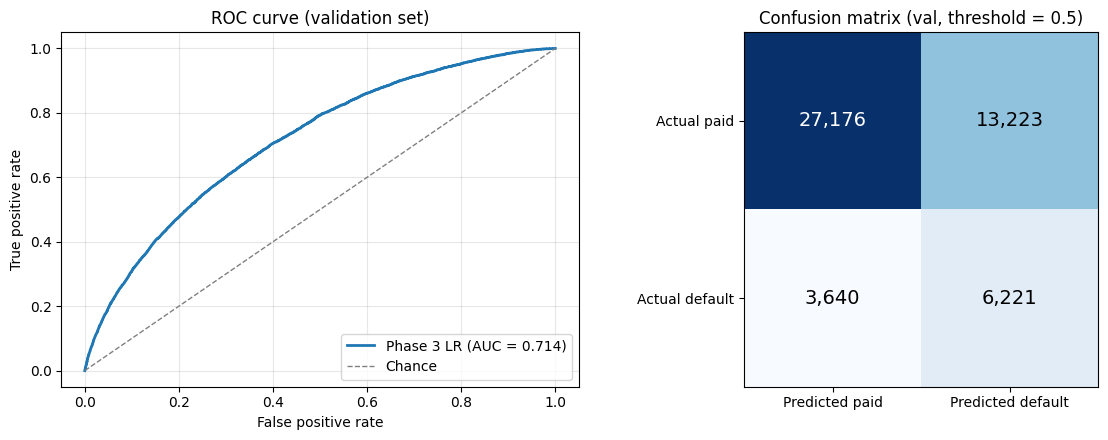

In [0]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, confusion_matrix

p_val = pipe.predict_proba(X_val)[:, 1]
fpr, tpr, _ = roc_curve(y_val, p_val)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(fpr, tpr, lw=2, label=f"Phase 3 LR (AUC = {val_roc:.3f})")
ax1.plot([0, 1], [0, 1], ls="--", color="grey", lw=1, label="Chance")
ax1.set_xlabel("False positive rate")
ax1.set_ylabel("True positive rate")
ax1.set_title("ROC curve (validation set)")
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

threshold = 0.5
cm = confusion_matrix(y_val, (p_val >= threshold).astype(int))
ax2.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax2.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)
ax2.set_xticks([0, 1]); ax2.set_xticklabels(["Predicted paid", "Predicted default"])
ax2.set_yticks([0, 1]); ax2.set_yticklabels(["Actual paid", "Actual default"])
ax2.set_title(f"Confusion matrix (val, threshold = {threshold})")

plt.tight_layout()
plt.show()

## Step 6 &mdash; Comparison to Phase 2

Putting this run next to the Phase 2 results so a grader can see at a glance that the Spark-sourced pipeline is producing comparable numbers.

In [0]:
comparison = pd.DataFrame([
    {"Model": "Phase 2 LogisticRegression (full data, sklearn)",
     "Val AUC-ROC": 0.7121, "Val AUC-PR": 0.3757},
    {"Model": "Phase 3 LogisticRegression (Gold Delta -> sklearn)",
     "Val AUC-ROC": round(val_roc, 4), "Val AUC-PR": round(val_pr, 4)},
])
comparison

,Model,Val AUC-ROC,Val AUC-PR
0,"Phase 2 LogisticRegression (full data, sklearn)",0.7121,0.3757
1,Phase 3 LogisticRegression (Gold Delta -> skle...,0.7136,0.3781


## Step 7 &mdash; Save the fitted pipeline

The full sklearn pipeline (preprocessors + classifier) is serialized with joblib for reuse in the macro-integration notebook and for inspection after the session ends.

In [0]:
import joblib, os
os.makedirs("/tmp/phase3", exist_ok=True)
path = "/tmp/phase3/phase3_logreg.joblib"
joblib.dump(pipe, path)
print(f"Saved pipeline to {path}")

Saved pipeline to /tmp/phase3/phase3_logreg.joblib
